In [2]:
# The tanh + avg pooling version ( LeCun et al. 1998)
ARCH_NAME  = "classic"
ARCH_LABEL = "LeNet-5 (1998): tanh + AvgPool"
ACTIVATION = "tanh"      
POOLING    = "avg"      

In [3]:
import json, math, time, pathlib, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")

DEVICE  = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
SEEDS   = [37, 42, 73]
EPOCHS  = 15
BATCH   = 128
RESULTS = pathlib.Path("results"); (RESULTS / "figures").mkdir(parents=True, exist_ok=True)

print(f"device        : {DEVICE}")
print(f"architecture  : {ARCH_LABEL}")
print(f"seeds         : {SEEDS}")
print(f"epochs/batch  : {EPOCHS} / {BATCH}")

device        : mps
architecture  : LeNet-5 (1998): tanh + AvgPool
seeds         : [37, 42, 73]
epochs/batch  : 15 / 128


### NOTE

We chose a set of 3 seed values for the following reasons:

1) Since batch norm and other stable training techniques were out of scope, running the model on 3 different seeds changes the batch orders - as in the elements of each batch - thus helping us step towards a more genralized model.

2) Different seed values imply different initial weights and enable us to explore the parameter space.



In [6]:
# Data 

MEAN, STD = 0.1307, 0.3081

def load_mnist(root="data", val_size=6_000, split_seed=0):
    """Load MNIST once, normalise, pad 28→32, and park it all on the GPU.

    LeNet-5 has ~62k parameters, so a normal DataLoader spends far more time in
    Python than the model spends computing. The whole dataset is only ~250 MB as
    float32, so we move it to the device once and take batches as index slices.
    This is ~50x faster here and is what makes 90 runs affordable.
    """
    tr = datasets.MNIST(root, train=True,  download=True)
    te = datasets.MNIST(root, train=False, download=True)

    def prep(ds):
        x = ds.data.float().div_(255.).sub_(MEAN).div_(STD).unsqueeze(1)
        x = F.pad(x, (2, 2, 2, 2), value=(0.0 - MEAN) / STD)   # pad with *normalised* black
        return x.to(DEVICE), ds.targets.to(DEVICE)

    xtr, ytr = prep(tr)
    xte, yte = prep(te)
    g    = torch.Generator().manual_seed(split_seed)          # split is fixed across all runs
    perm = torch.randperm(len(xtr), generator=g).to(DEVICE)
    vi, ti = perm[:val_size], perm[val_size:]
    return (xtr[ti], ytr[ti]), (xtr[vi], ytr[vi]), (xte, yte)

train_set, val_set, test_set = load_mnist()
print(f"train {tuple(train_set[0].shape)}   val {tuple(val_set[0].shape)}   test {tuple(test_set[0].shape)}")
print(f"resides on: {train_set[0].device}   ~{train_set[0].element_size()*train_set[0].nelement()/1e6:.0f} MB")

train (54000, 1, 32, 32)   val (6000, 1, 32, 32)   test (10000, 1, 32, 32)
resides on: mps:0   ~221 MB


In [7]:
# Defining the network

class LeNet5(nn.Module):
    """32×32 → 6@28×28 → 6@14×14 → 16@10×10 → 16@5×5 → 120 → 84 → 10"""
    def __init__(self, activation="tanh", pooling="avg"):
        super().__init__()
        A = nn.Tanh if activation == "tanh" else nn.ReLU
        P = nn.AvgPool2d if pooling == "avg" else nn.MaxPool2d
        self.net = nn.Sequential(
            nn.Conv2d(1,   6, 5), A(), P(2),     # C1, S2
            nn.Conv2d(6,  16, 5), A(), P(2),     # C3, S4
            nn.Conv2d(16,120, 5), A(),           # C5
            nn.Flatten(),
            nn.Linear(120, 84),   A(),           # F6
            nn.Linear(84,  10),                  # output
        )
    def forward(self, x):
        return self.net(x)

_m = LeNet5(ACTIVATION, POOLING)
print(_m)
print(f"\ntrainable parameters: {sum(p.numel() for p in _m.parameters()):,}")

LeNet5(
  (net): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): Tanh()
    (11): Linear(in_features=84, out_features=10, bias=True)
  )
)

trainable parameters: 61,706


In [9]:
# Training loop - Void of any stable training tech

@torch.no_grad()
def evaluate(model, x, y, bs=2000):
    model.eval()
    loss = correct = 0.0
    for i in range(0, len(x), bs):
        out = model(x[i:i+bs])
        loss    += F.cross_entropy(out, y[i:i+bs], reduction="sum").item()
        correct += (out.argmax(1) == y[i:i+bs]).sum().item()
    return loss / len(x), correct / len(x)


def run(cfg, seed):

    xtr, ytr = train_set
    xva, yva = val_set
    torch.manual_seed(seed)
    model = LeNet5(ACTIVATION, POOLING).to(DEVICE)

    if cfg["opt"] == "SGD":
        opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"])
    else:
        opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

    g = torch.Generator().manual_seed(seed)
    n = len(xtr)
    hist, diverged_at = [], None

    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = torch.randperm(n, generator=g).to(DEVICE)
        run_loss = 0.0; run_corr = 0
        for i in range(0, n, BATCH):
            idx    = perm[i:i+BATCH]
            xb, yb = xtr[idx], ytr[idx]
            opt.zero_grad(set_to_none=True)
            out  = model(xb)
            loss = F.cross_entropy(out, yb)
            loss.backward()
            opt.step()
            run_loss += loss.item() * len(idx)
            run_corr += (out.argmax(1) == yb).sum().item()

        train_loss, train_acc = run_loss / n, run_corr / n
        if not math.isfinite(train_loss):
            diverged_at = ep
            break
        val_loss, val_acc = evaluate(model, xva, yva)
        hist.append(dict(epoch=ep, train_loss=train_loss, train_acc=train_acc,
                         val_loss=val_loss, val_acc=val_acc))

    test_loss, test_acc = (float("nan"), float("nan")) if diverged_at else evaluate(model, *test_set)
    return hist, diverged_at, test_loss, test_acc

In [ ]:
# the optimiser cases: 
'''
1) SGD: a full 3x3 sweep over (lr, momentum) so it can be read as a heatmap.
2) Adam: a 5-step ladder spanning 2.5 orders of magnitude, from 'too small' to unstable.
3) Plus one deliberately over-momentumed SGD run.

'''

CONFIGS = []
for lr in [0.001, 0.01, 0.1]:
    for m in [0.0, 0.5, 0.9]:
        CONFIGS.append(dict(opt="SGD", lr=lr, momentum=m))
for lr in [1e-4, 1e-3, 3e-3, 1e-2, 3e-2]:
    CONFIGS.append(dict(opt="Adam", lr=lr, momentum=float("nan")))
CONFIGS.append(dict(opt="SGD", lr=0.1, momentum=0.99))     # momentum pushed too far

def label(c):
    return (f"SGD lr={c['lr']:g} m={c['momentum']:g}" if c["opt"] == "SGD"
            else f"Adam lr={c['lr']:g}")

print(f"{len(CONFIGS)} configurations x {len(SEEDS)} seeds = {len(CONFIGS)*len(SEEDS)} runs")
for c in CONFIGS: print("  ", label(c))

15 configurations x 3 seeds = 45 runs
   SGD lr=0.001 m=0
   SGD lr=0.001 m=0.5
   SGD lr=0.001 m=0.9
   SGD lr=0.01 m=0
   SGD lr=0.01 m=0.5
   SGD lr=0.01 m=0.9
   SGD lr=0.1 m=0
   SGD lr=0.1 m=0.5
   SGD lr=0.1 m=0.9
   Adam lr=0.0001
   Adam lr=0.001
   Adam lr=0.003
   Adam lr=0.01
   Adam lr=0.03
   SGD lr=0.1 m=0.99


In [16]:
hist_path, test_path = RESULTS / f"{ARCH_NAME}_history.csv", RESULTS / f"{ARCH_NAME}_test.csv"
hist_rows, test_rows = [], []
t_start = time.time()

for ci, cfg in enumerate(CONFIGS, 1):
    for seed in SEEDS:
        t0 = time.time()
        hist, diverged_at, test_loss, test_acc = run(cfg, seed)
        for h in hist:
            hist_rows.append(dict(arch=ARCH_NAME, **cfg, seed=seed, label=label(cfg), **h))
        test_rows.append(dict(arch=ARCH_NAME, **cfg, seed=seed, label=label(cfg),
                              diverged_at=diverged_at, test_loss=test_loss, test_acc=test_acc,
                              final_val_acc=hist[-1]["val_acc"] if hist else float("nan"),
                              epochs_completed=len(hist)))
        
        pd.DataFrame(hist_rows).to_csv(hist_path, index=False)
        pd.DataFrame(test_rows).to_csv(test_path, index=False)
        status = (f"DIVERGED at epoch {diverged_at}" if diverged_at
                  else f"test {test_acc:6.2%}")
        print(f"[{ci:2}/{len(CONFIGS)}] {label(cfg):24} seed {seed}  "
              f"{status:22} {time.time()-t0:5.1f}s")

history = pd.DataFrame(hist_rows)
tests   = pd.DataFrame(test_rows)
print(f"\n{len(CONFIGS)*len(SEEDS)} runs in {(time.time()-t_start)/60:.1f} min  →  {hist_path}, {test_path}")

[ 1/15] SGD lr=0.001 m=0         seed 37  test 78.84%             11.9s
[ 1/15] SGD lr=0.001 m=0         seed 42  test 80.40%             11.6s
[ 1/15] SGD lr=0.001 m=0         seed 73  test 79.03%             11.6s
[ 2/15] SGD lr=0.001 m=0.5       seed 37  test 88.58%             12.0s
[ 2/15] SGD lr=0.001 m=0.5       seed 42  test 88.35%             12.0s
[ 2/15] SGD lr=0.001 m=0.5       seed 73  test 88.51%             11.9s
[ 3/15] SGD lr=0.001 m=0.9       seed 37  test 95.85%             12.4s
[ 3/15] SGD lr=0.001 m=0.9       seed 42  test 95.71%             11.9s
[ 3/15] SGD lr=0.001 m=0.9       seed 73  test 96.08%             11.9s
[ 4/15] SGD lr=0.01 m=0          seed 37  test 95.89%             11.7s
[ 4/15] SGD lr=0.01 m=0          seed 42  test 95.71%             11.6s
[ 4/15] SGD lr=0.01 m=0          seed 73  test 96.10%             11.6s
[ 5/15] SGD lr=0.01 m=0.5        seed 37  test 97.87%             12.3s
[ 5/15] SGD lr=0.01 m=0.5        seed 42  test 97.91%           

[ 1/15] SGD lr=0.001 m=0         seed 42  test 80.40%             11.7s


[ 1/15] SGD lr=0.001 m=0         seed 73  test 79.03%             11.3s


[ 2/15] SGD lr=0.001 m=0.5       seed 37  test 88.58%             12.1s


[ 2/15] SGD lr=0.001 m=0.5       seed 42  test 88.35%             11.8s


...

[14/15] Adam lr=0.03             seed 42  test 88.16%             36.9s


[14/15] Adam lr=0.03             seed 73  test 89.90%             40.3s


[15/15] SGD lr=0.1 m=0.99        seed 37  test 13.64%             11.9s


[15/15] SGD lr=0.1 m=0.99        seed 42  test 24.78%             11.8s


[15/15] SGD lr=0.1 m=0.99        seed 73  test 25.20%             12.8s

45 runs in 15.3 min  →  results/classic_history.csv, results/classic_test.csv


In [17]:

INK, INK2, GRID_C = "#0b0b0b", "#52514e", "#dcdcd8"
SGD_RAMP  = ["#9dc2ec", "#4a8fdd", "#1a5aa8"]                          # LR
ADAM_RAMP = ["#f7c3a8", "#f19a6e", "#eb6834", "#c74e20", "#8f3614"]    # LR
MOM_RAMP  = ["#bcd6f2", "#6ba4e3", "#2a78d6", "#12406f"]               # Momentum 
SGD_HUE, ADAM_HUE = "#2a78d6", "#eb6834"
DIVERGED_C = "#e34948"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": GRID_C, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID_C, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

def tidy(ax, title=None, xlabel=None, ylabel=None):
    if title:  ax.set_title(title, loc="left", color=INK, fontweight="bold", pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    return ax

def band(ax, df, color, lab, ycol, dashed=False):
    """Mean line across seeds + a min/max band. A wide band = an unreliable config."""
    g  = df.groupby("epoch")[ycol]
    mu, lo, hi = g.mean(), g.min(), g.max()
    ax.fill_between(mu.index, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(mu.index, mu.values, color=color, label=lab,
            linestyle="--" if dashed else "-")
    return mu

def save(fig, name):
    p = RESULTS / "figures" / f"{ARCH_NAME}_{name}.png"
    fig.savefig(p); print("saved", p)

saved results/figures/classic_fig1_train_loss.png


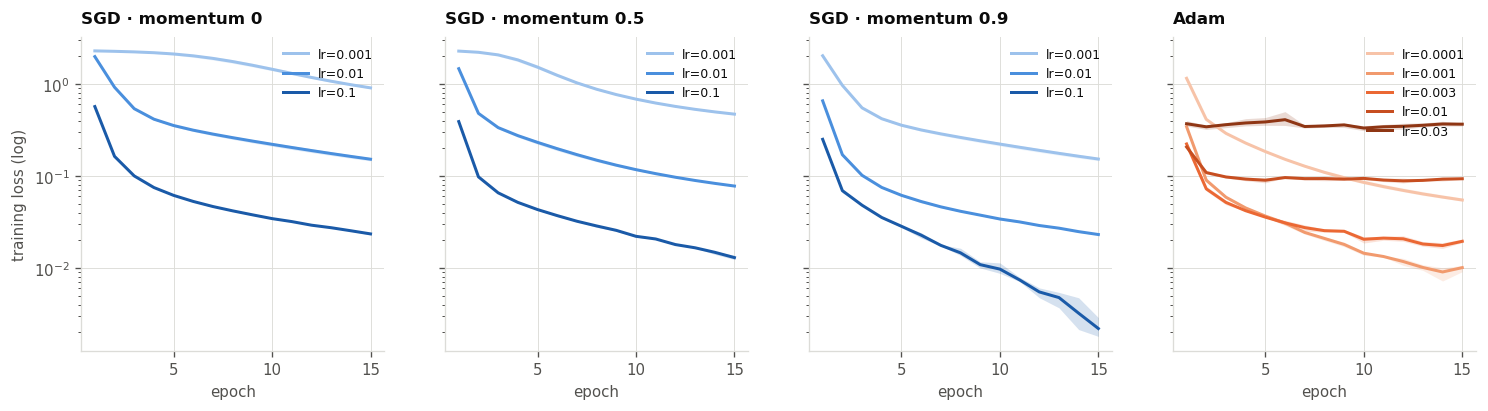

In [23]:

panels = [("SGD", 0.0), ("SGD", 0.5), ("SGD", 0.9), ("Adam", None)]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)

for ax, (opt, m) in zip(axes, panels):
    if opt == "SGD":
        sub  = history[(history.opt == "SGD") & (history.momentum == m)]
        lrs  = sorted(sub.lr.unique()); ramp = SGD_RAMP
        ttl  = f"SGD · momentum {m:g}"
    else:
        sub  = history[history.opt == "Adam"]
        lrs  = sorted(sub.lr.unique()); ramp = ADAM_RAMP
        ttl  = "Adam"
    for c, lr in zip(ramp, lrs):
        band(ax, sub[sub.lr == lr], c, f"lr={lr:g}", "train_loss")
    ax.set_yscale("log")
    ax.legend(loc="upper right", fontsize=7.5)
    tidy(ax, ttl, "epoch", "training loss (log)" if ax is axes[0] else None)

# fig.suptitle(f"Training loss — {ARCH_LABEL}", x=0.005, ha="left",
#              fontweight="bold", color=INK, fontsize=12)

save(fig, "fig1_train_loss"); plt.show()

saved results/figures/classic_fig2_val_acc.png


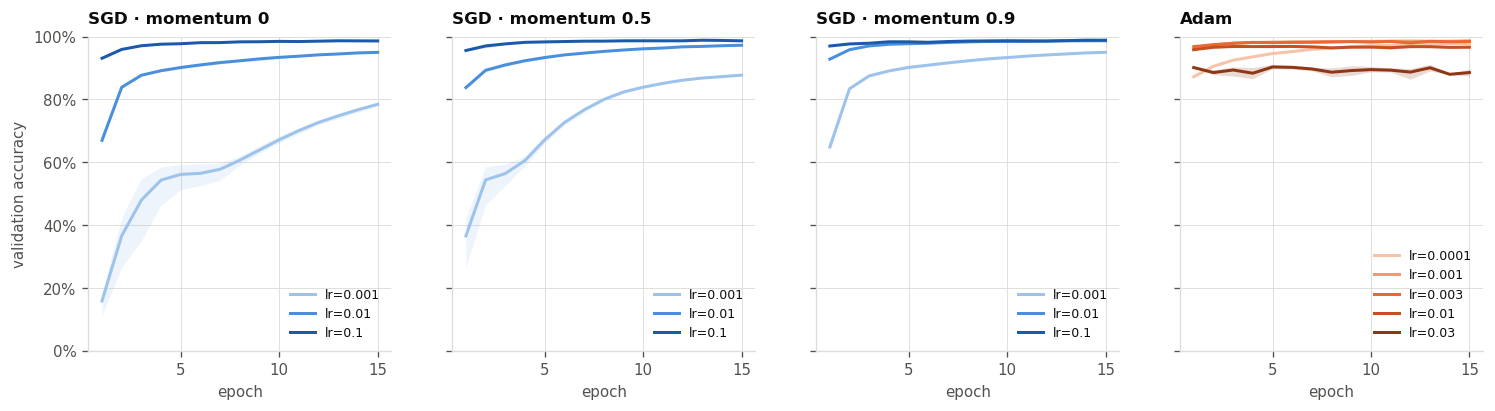

In [22]:
# Validation Plots
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)

for ax, (opt, m) in zip(axes, panels):
    if opt == "SGD":
        sub = history[(history.opt == "SGD") & (history.momentum == m)]
        ramp, ttl = SGD_RAMP, f"SGD · momentum {m:g}"
    else:
        sub = history[history.opt == "Adam"]
        ramp, ttl = ADAM_RAMP, "Adam"
    for c, lr in zip(ramp, sorted(sub.lr.unique())):
        band(ax, sub[sub.lr == lr], c, f"lr={lr:g}", "val_acc")
    ax.set_ylim(0.0, 1.0)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc="lower right", fontsize=7.5)
    tidy(ax, ttl, "epoch", "validation accuracy" if ax is axes[0] else None)

# fig.suptitle(f"Validation accuracy — {ARCH_LABEL}", x=0.005, ha="left",
#              fontweight="bold", color=INK, fontsize=12)
save(fig, "fig2_val_acc"); plt.show()

saved results/figures/classic_fig3_momentum.png


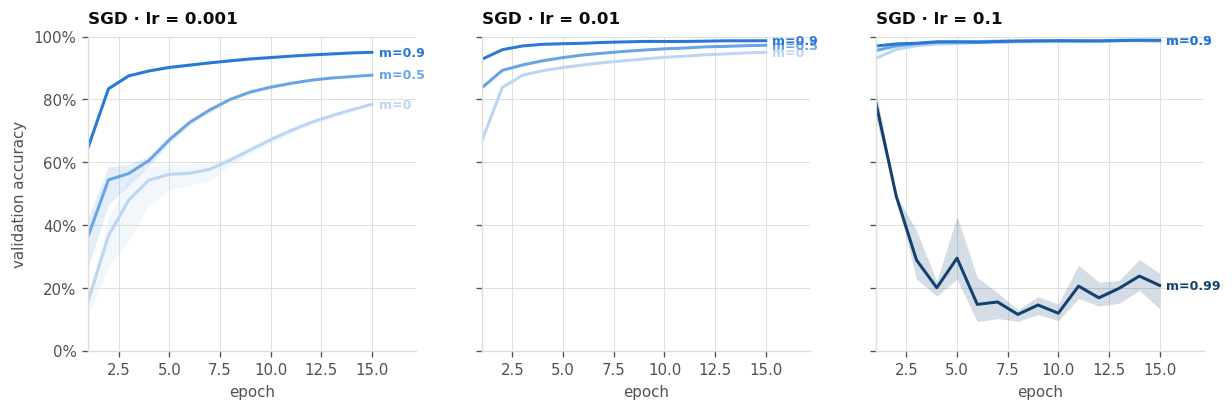

In [26]:
# Momentum v/s Learning rates ( variable momenta and fixed LR)
lrs = [0.001, 0.01, 0.1]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)

for ax, lr in zip(axes, lrs):
    sub = history[(history.opt == "SGD") & (history.lr == lr)]
    moms = sorted(sub.momentum.unique())
    for c, m in zip(MOM_RAMP, moms):
        mu = band(ax, sub[sub.momentum == m], c, f"m={m:g}", "val_acc")
        if len(mu):                                   
            ax.annotate(f"m={m:g}", (mu.index[-1], mu.values[-1]),
                        xytext=(4, 0), textcoords="offset points",
                        color=c, fontsize=7.5, va="center", fontweight="bold")
    ax.set_ylim(0.0, 1.0); ax.set_xlim(1, EPOCHS + 2.2)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    tidy(ax, f"SGD · lr = {lr:g}", "epoch", "validation accuracy" if ax is axes[0] else None)

# fig.suptitle(f"Momentum at a fixed learning rate — {ARCH_LABEL}", x=0.005, ha="left",
#              fontweight="bold", color=INK, fontsize=12)


'''Momentum acts as a learning-rate multiplier: it rescues a step 
    that is too small and destroys one that is already too big. '''
         
save(fig, "fig3_momentum"); plt.show()

saved results/figures/classic_fig4_heatmap.png


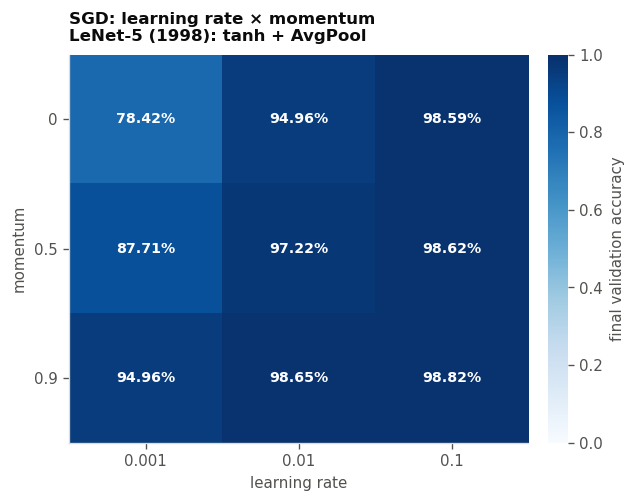

In [32]:
# SGD Val Accuracy Heatmap
sgd  = tests[(tests.opt == "SGD") & (tests.momentum.isin([0.0, 0.5, 0.9]))]
mat  = sgd.pivot_table(index="momentum", columns="lr", values="final_val_acc",
                       aggfunc="mean", dropna=False)
divc = sgd.assign(d=sgd.diverged_at.notna()).pivot_table(
           index="momentum", columns="lr", values="d", aggfunc="sum", dropna=False)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
im = ax.imshow(mat.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")  
ax.set_xticks(range(len(mat.columns)), [f"{v:g}" for v in mat.columns])
ax.set_yticks(range(len(mat.index)),   [f"{v:g}" for v in mat.index])
ax.grid(False)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v, nd = mat.values[i, j], int(divc.values[i, j])
        if nd == len(SEEDS):
            ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, facecolor="#fdecec",
                                       edgecolor=DIVERGED_C, linewidth=1.4, hatch="///"))
            txt, col = "diverged\n3/3 seeds", DIVERGED_C
        else:
            txt = f"{v:.2%}" + (f"\n{nd}/{len(SEEDS)} diverged" if nd else "")
            col = "white" if v > 0.55 else INK
        ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=8.5, fontweight="bold")

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("final validation accuracy", color=INK2); cb.outline.set_visible(False)
tidy(ax, f"SGD: learning rate × momentum\n{ARCH_LABEL}", "learning rate", "momentum")
save(fig, "fig4_heatmap"); plt.show()

saved results/figures/classic_fig5_lr_sensitivity.png


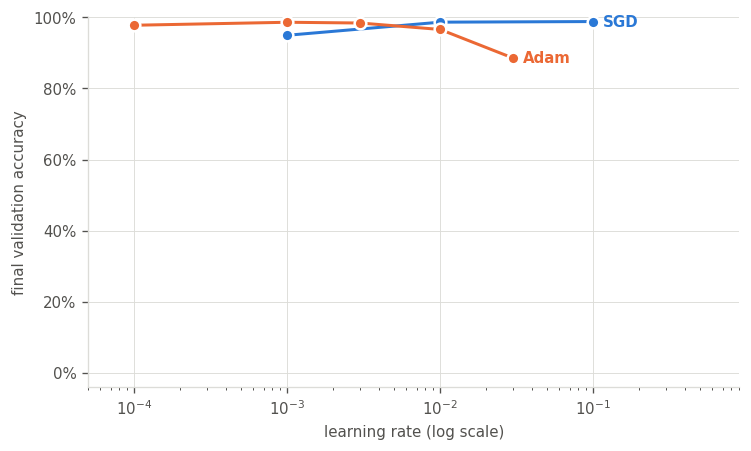

In [37]:
# LR v/s Val Accuracy
fig, ax = plt.subplots(figsize=(7, 4))

best_sgd = (tests[tests.opt == "SGD"].groupby(["lr", "momentum"], as_index=False)
            .final_val_acc.mean().sort_values("final_val_acc", ascending=False)
            .drop_duplicates("lr").sort_values("lr"))
adam = tests[tests.opt == "Adam"].groupby("lr", as_index=False).final_val_acc.mean()

for d, c, lab in [(best_sgd, SGD_HUE, "SGD (best momentum per lr)"),
                  (adam,     ADAM_HUE, "Adam")]:
    y = d.final_val_acc.fillna(0)
    ax.plot(d.lr, y, color=c, marker="o", markersize=7, label=lab,
            markeredgecolor="white", markeredgewidth=1.5)          # 2px surface ring
    ax.annotate(lab.split(" (")[0], (d.lr.iloc[-1], y.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=c, fontweight="bold",
                fontsize=9, va="center")

for _, r in tests[tests.diverged_at.notna()].groupby(["opt", "lr"]).first().reset_index().iterrows():
    ax.scatter([r.lr], [0.0], marker="x", s=70, color=DIVERGED_C, zorder=5)

ax.set_xscale("log"); ax.set_ylim(-0.04, 1.0); ax.set_xlim(5e-5, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
tidy(ax, "",
     "learning rate (log scale)", "final validation accuracy")

save(fig, "fig5_lr_sensitivity"); plt.show()

saved results/figures/classic_fig6_test_acc.png


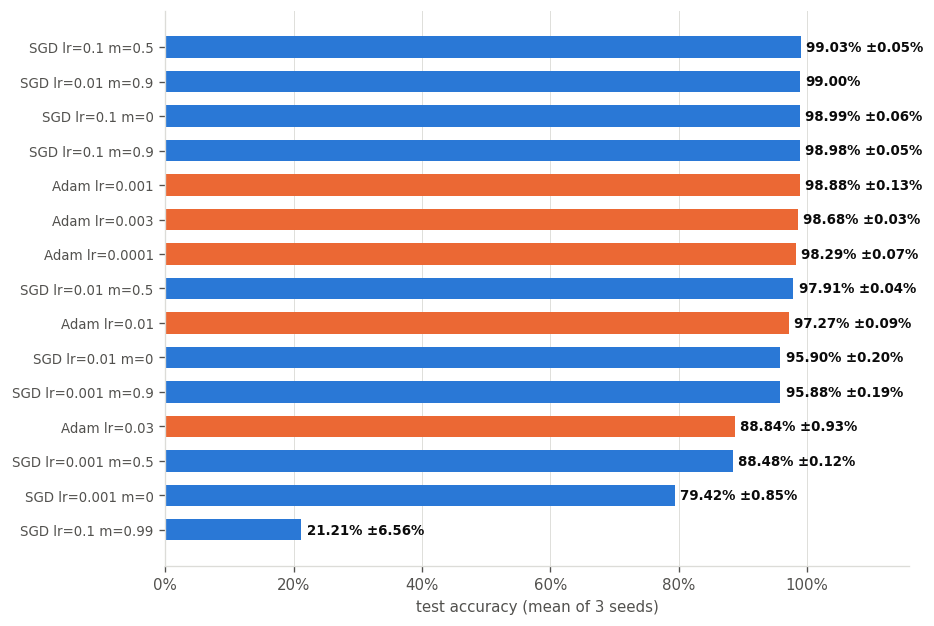

In [38]:
# Final Test Accuracy Comparison
agg = (tests.groupby(["label", "opt"], as_index=False)
       .agg(test_acc=("test_acc", "mean"), sd=("test_acc", "std"),
            ndiv=("diverged_at", lambda s: s.notna().sum()))
       .sort_values("test_acc", ascending=True, na_position="first"))

fig, ax = plt.subplots(figsize=(8, 6))
ys = np.arange(len(agg))
for y, r in zip(ys, agg.itertuples()):
    if r.ndiv == len(SEEDS):
        ax.barh(y, 1.0, color="#fdecec", edgecolor=DIVERGED_C, hatch="///", height=0.62)
        ax.text(0.012, y, "diverged — no test score", va="center",
                color=DIVERGED_C, fontsize=8, fontweight="bold")
    else:
        c = SGD_HUE if r.opt == "SGD" else ADAM_HUE
        ax.barh(y, r.test_acc, color=c, height=0.62)
        err = f" ±{r.sd:.2%}" if r.sd == r.sd and r.sd > 0 else ""
        ax.text(r.test_acc + 0.008, y, f"{r.test_acc:.2%}{err}", va="center",
                color=INK, fontsize=8, fontweight="bold")

ax.set_yticks(ys, agg.label, fontsize=8)
ax.set_xlim(0, 1.16); ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
tidy(ax, "", "test accuracy (mean of 3 seeds)")

save(fig, "fig6_test_acc"); plt.show()

### Summary table

In [15]:

summary = (tests.groupby(["opt", "lr", "momentum"], dropna=False, as_index=False)
           .agg(test_acc_mean=("test_acc", "mean"), test_acc_sd=("test_acc", "std"),
                val_acc_mean=("final_val_acc", "mean"),
                seeds_diverged=("diverged_at", lambda s: s.notna().sum()))
           .sort_values("test_acc_mean", ascending=False, na_position="last"))
summary["verdict"] = np.where(
    summary.seeds_diverged == len(SEEDS), "diverged (all seeds)",
    np.where(summary.seeds_diverged > 0, "unstable (some seeds)",
    np.where(summary.test_acc_mean > 0.98, "strong",
    np.where(summary.test_acc_mean > 0.90, "works", "underfits"))))
summary.to_csv(RESULTS / f"{ARCH_NAME}_summary.csv", index=False)
summary.style.format({"test_acc_mean": "{:.2%}", "test_acc_sd": "{:.2%}",
                      "val_acc_mean": "{:.2%}", "lr": "{:g}", "momentum": "{:g}"},
                     na_rep="—").hide(axis="index")

opt,lr,momentum,test_acc_mean,test_acc_sd,val_acc_mean,seeds_diverged,verdict
SGD,0.1,0.5,99.03%,0.05%,98.62%,0,strong
SGD,0.01,0.9,99.00%,0.00%,98.65%,0,strong
SGD,0.1,0,98.99%,0.06%,98.59%,0,strong
SGD,0.1,0.9,98.98%,0.05%,98.82%,0,strong
Adam,0.001,—,98.88%,0.13%,98.62%,0,strong
Adam,0.003,—,98.68%,0.03%,98.41%,0,strong
Adam,0.0001,—,98.29%,0.07%,97.78%,0,strong
SGD,0.01,0.5,97.91%,0.04%,97.22%,0,works
Adam,0.01,—,97.27%,0.09%,96.59%,0,works
SGD,0.01,0,95.90%,0.20%,94.96%,0,works


## 7 · Discussion

## What to say about this

**1. There is no "best optimizer" — there is a best (optimizer, learning rate) pair.**
The spread *within* SGD across learning rates is far larger than the gap *between*
SGD and Adam at their respective best settings. Tuning the learning rate buys more
than switching optimizer does.

**2. Momentum is a learning-rate multiplier, not a free improvement.** Read Figure 3
left to right: at lr=0.001 momentum rescues a step that is too small; at lr=0.1 it
destroys a step that was already too big. The effective step is roughly
lr / (1 − momentum), so m=0.9 multiplies it by 10 and m=0.99 by 100. That is why the
m=0.99 run exists in this sweep.

**3. Adam's usable window is lower and narrower.** Its per-parameter scaling means a
learning rate that suits SGD is catastrophic for Adam. Adam is not "no tuning
required" — it is "different defaults, still tuned". What Adam genuinely buys here
is speed in the first two or three epochs.

**4. Error bands are the honest part.** Where the shaded band is narrow, the
configuration is reliable. Where it is wide, or where a cell reads "diverged 2/3
seeds", a single run would have told you a story that the next run contradicts.

**5. The caveat to state out loud.** This is MNIST with a 62k-parameter network. Every
reasonable configuration lands between 98% and 99%, and differences of a tenth of a
percent are inside seed noise — do not rank two configurations on them. What this
experiment shows clearly is the *shape* of the failure modes, not a leaderboard.